In [1]:
from dotenv import load_dotenv, find_dotenv
import os
load_dotenv(find_dotenv(),override=True)
from IPython.display import Image, display
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [2]:
from langchain_core.output_parsers import JsonOutputParser
from langchain.output_parsers import PydanticOutputParser
from custom_types import SectionWebSearchResult, ReportGeneratorWorkflowState
from langchain_openai import ChatOpenAI
from topic_analyser import TopicAnalyzer
from web_researcher import WebResearcher
from section_writter import SectionWriter
from report_compiler import ReportCompiler
from custom_types import SectionOutLine
from typing import Dict, List,Optional

In [3]:
# Convenience function for LangGraph node
def topic_analyzer_node(state: ReportGeneratorWorkflowState) -> ReportGeneratorWorkflowState:
    """
    LangGraph node function for topic analysis.
    
    Args:
        state: Current workflow state
        
    Returns:
        Updated workflow state
    """
    
    analyzer = TopicAnalyzer()
    state.sections_outline = analyzer.analyze_topic(topic=state.topic, requirements=state.requirements, 
                                                   target_audience=state.target_audience)
    
    return state
        

In [4]:
async def researcher_node(state: ReportGeneratorWorkflowState) -> ReportGeneratorWorkflowState:
    """
    LangGraph node function for web research.
    
    Args:
        state: Current workflow state
        
    Returns:
        Updated workflow state
    """
 
    researcher = WebResearcher()
    sectionWebSearchResults = await researcher.research_sections(state.sections_outline)
    print(f"*****Research completed for {len(sectionWebSearchResults)} sections.")
    state.sectionWebSearchResults = sectionWebSearchResults
  
   
    return state

In [5]:
from custom_utils import CustomUtils



In [6]:
async def section_writer_node(state: ReportGeneratorWorkflowState) -> ReportGeneratorWorkflowState:
    """
    LangGraph node function for section writer.
    
    Args:
        state: Current workflow state
        
    Returns:
        Updated workflow state
    """
    section_writter_dict = CustomUtils.merge_sections_by_title(outlines=state.sections_outline,
                                                               search_results=state.sectionWebSearchResults)
  
    
    section_writer = SectionWriter()
  
    sections = await section_writer.write_all_sections(section_writter_dict,state.target_audience)
    print(f"****Section writing completed for {len(sections)} sections.")
    state.sections = sections
   
    return state

In [7]:
def report_compiler_node(state: ReportGeneratorWorkflowState) -> ReportGeneratorWorkflowState:
    """
    LangGraph node function for report compilation.
    
    Args:
        state: Current workflow state
        
    Returns:
        Updated workflow state
    """
   
    
    # Assuming a method to compile sections into a final report
    report_compiler = ReportCompiler()
    final_report = report_compiler.compile_report(topic=state.topic , sections=state.sections)
    state.final_report = final_report
    report_path = report_compiler.save_report(report_content=final_report, topic=state.topic)
    state.final_report_path = report_path
    print(f"****Final report compiled at: {state.final_report_path}")
   
    return state

In [8]:
from langgraph.graph import StateGraph, END, START 
from IPython.display import Image, display
from langgraph.checkpoint.memory import MemorySaver

def build_workflow():
        """
        Builds the LangGraph StateGraph defining the report generation workflow.
        """
        workflow = StateGraph(ReportGeneratorWorkflowState)

        # 1. Add Nodes for each agent
        workflow.add_node("analyze_topic", topic_analyzer_node)
        workflow.add_node("research_web", researcher_node)
        workflow.add_node("write_sections", section_writer_node)
        workflow.add_node("compile_report", report_compiler_node)

        # 2. Define the Entry Point
        workflow.set_entry_point("analyze_topic")

        # 3. Define Edges (flow between nodes)
        workflow.add_edge("analyze_topic", "research_web")
         
        # workflow.add_edge("research_web", "write_sections")
        # workflow.add_edge("write_sections", END)
        # workflow.add_edge("write_sections", "compile_report")
        # workflow.add_edge("compile_report", END) # The report compilation is the end of the main flow
        workflow.add_edge("research_web", END)
        # Compile the graph
        memory=MemorySaver()
        graph = workflow.compile(checkpointer=memory)
        display(Image(graph.get_graph().draw_mermaid_png()))
        return graph

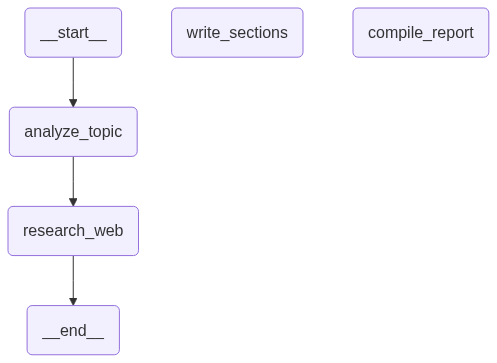

c:\VSCodeWorkSpace\.venv\Lib\site-packages\pydantic\main.py:463: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `SectionOutLine` - serialized value may not be as expected [input_value={'title': 'Introduction t... learning experiences.'}, input_type=dict])
  PydanticSerializationUnexpectedValue(Expected `SectionOutLine` - serialized value may not be as expected [input_value={'title': 'Benefits of AI... for diverse learners.'}, input_type=dict])
  PydanticSerializationUnexpectedValue(Expected `SectionOutLine` - serialized value may not be as expected [input_value={'title': 'Challenges and...bias in AI algorithms.'}, input_type=dict])
  PydanticSerializationUnexpectedValue(Expected `SectionOutLine` - serialized value may not be as expected [input_value={'title': 'Case Studies o...tors and policymakers.'}, input_type=dict])
  PydanticSerializationUnexpectedValue(Expected `SectionOutLine` - serialized value may not be as expected [input_value={'ti

  Researching for section: 'Introduction to AI in Education' with query: 'Introduction to AI in Education: An overview of artificial intelligence and its integration into modern educational systems, highlighting the significance of AI technologies in transforming teaching and learning experiences.'
  Researching for section: 'Benefits of AI in Education' with query: 'Benefits of AI in Education: A detailed exploration of the advantages AI brings to education, including personalized learning, enhanced engagement, administrative efficiency, and improved accessibility for diverse learners.'
  Researching for section: 'Challenges and Ethical Considerations' with query: 'Challenges and Ethical Considerations: An analysis of the potential challenges and ethical dilemmas associated with AI in education, such as data privacy concerns, the digital divide, and the risk of bias in AI algorithms.'
  Researching for section: 'Case Studies of AI Implementation' with query: 'Case Studies of AI Implem

In [9]:
thread = {'configurable': {'thread_id': '1'}}
graph = build_workflow()

prompt = {
    'topic': "The impact of AI on modern education",
    'target_audience': "Educators and policymakers",
    'requirements': "A comprehensive report covering the benefits, challenges, and future prospects of AI in education.",
  
}

result = await graph.ainvoke(prompt, thread)
print(f"Workflow completed with state: {result}")
# print(f"Final report path: {result.final_report_path}")  
# async for chunk in graph.astream(prompt, thread):
#     print(chunk)
             
             